# Notebook 04 — Baselines: Logistic Regression, Linear SVM & Leakage Probe
**CMPE-255 | Mental Health & Crisis Signal Mining on Social Media**  
**Owner: Gunanidhi Ramakrishnan**  
**Environment: Google Colab**

---

### What this notebook does

| Experiment | Model | Feature Input | Expected macro-F1 |
|---|---|---|---|
| **EXP-1** | Logistic Regression | TF-IDF unigrams + bigrams | 0.62 – 0.70 |
| **EXP-2** | Linear SVM | TF-IDF unigrams + bigrams | 0.65 – 0.72 |
| **LP-Probe** | Logistic Regression | Surface stats only (no text) | ≤ 0.40 |

Each classical model is run under **three class-balancing conditions** — no balancing,
class-weighted loss, and SMOTE oversampling — so we can compare their effect directly.

The **LP-Probe** (Leakage Probe) is the single most important sanity check in the project:
it asks _"how much of our accuracy comes purely from subreddit-style formatting cues
rather than mental-health signal?"_ A macro-F1 ≥ 0.50 on surface features alone
is a red flag that the preprocessing strip step needs revisiting.

---

### Prerequisites
Run **Notebook 02** (Data Preprocessing) and **Notebook 03** (Feature Engineering)
first and save their outputs to the Google Drive folder configured below.

Required files in `DRIVE_ROOT/data/processed/`:
- `train.parquet` — training set (text + integer labels)
- `test.parquet`  — held-out test set

Required files in `DRIVE_ROOT/artifacts/`:
- `X_train_tfidf.npz` — sparse TF-IDF matrix for training set
- `X_test_tfidf.npz`  — sparse TF-IDF matrix for test set
- `X_train_engineered.npz` — surface-stats + NRC features for training set
- `X_test_engineered.npz`  — surface-stats + NRC features for test set

In [1]:
# ============================================================
# CELL 1 — Package Installation
# ------------------------------------------------------------
# Google Colab ships with scikit-learn, numpy, pandas, matplotlib,
# and seaborn pre-installed, so we only need imbalanced-learn for SMOTE.
# The --quiet flag suppresses verbose pip output.
# ============================================================
!pip install imbalanced-learn --quiet
print('Packages ready.')

Packages ready.


In [2]:
# ============================================================
# CELL 2 — Mount Google Drive
# ------------------------------------------------------------
# This gives the notebook access to files you saved on Drive
# (parquet files from NB-02, feature matrices from NB-03).
# A browser popup will ask you to authorise access — that is expected.
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted at /content/drive')

Mounted at /content/drive
Drive mounted at /content/drive


In [ ]:
# ============================================================
# CELL 3 — Project Path Configuration
# ------------------------------------------------------------
# Edit DRIVE_ROOT to match the folder you created on your Google Drive.
# Everything else is derived from it automatically.
# ============================================================
from pathlib import Path

# --- EDIT THIS LINE if your folder is named differently ---
DRIVE_ROOT = Path('/content/drive/MyDrive/CMPE255_Project')
# ----------------------------------------------------------

# Sub-directories
DATA_DIR      = DRIVE_ROOT / 'data'          # parquet files from NB-02
ARTIFACTS_DIR = DRIVE_ROOT / 'artifacts'     # feature matrices + vectorizer from NB-03
MODELS_DIR    = DRIVE_ROOT / 'models'        # where trained models will be saved
RESULTS_DIR   = DRIVE_ROOT / 'results'       # metrics.csv lives here
FIGURES_DIR   = DRIVE_ROOT / 'figures'       # saved plot PNGs

# Create output directories if they don't exist yet
for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Verify that the input files from earlier notebooks are accessible
expected_inputs = [
    DATA_DIR / 'train.parquet',
    DATA_DIR / 'test.parquet',
    ARTIFACTS_DIR / 'X_train_tfidf.npz',
    ARTIFACTS_DIR / 'X_test_tfidf.npz',
    ARTIFACTS_DIR / 'X_train_engineered.npz',
    ARTIFACTS_DIR / 'X_test_engineered.npz',
]

print('Input file check:')
all_found = True
for p in expected_inputs:
    status = '✅' if p.exists() else '❌ MISSING'
    print(f'  {status}  {p.name}')
    if not p.exists():
        all_found = False

if not all_found:
    print('\n⚠️  Some input files are missing.')
    print('   Please run Notebook 02 and Notebook 03 first,')
    print('   then save their output to the same Drive folder.')
else:
    print('\nAll input files found. Ready to run.')

In [4]:
# ============================================================
# CELL 4 — Standard Library Imports
# ============================================================
import random
import os
import json
from datetime import datetime

import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib
import warnings

# scikit-learn: models
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.calibration     import CalibratedClassifierCV

# scikit-learn: model selection & evaluation
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics         import (
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix,
)
from sklearn.preprocessing   import label_binarize

# imbalanced-learn: SMOTE oversampling (installed above)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')  # suppress sklearn convergence warnings during CV

# Clean plot style for all figures in this notebook
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('All imports successful.')

All imports successful.


In [ ]:
# ============================================================
# CELL 5 — Project Constants
# ============================================================

# ---- Random seed ----
RANDOM_SEED = 42

def seed_everything(seed=RANDOM_SEED):
    """Set the random seed for Python built-ins, NumPy, and PyTorch (if available)."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass

seed_everything()

# ---- Label map (7-class Sarkar dataset) ----
CLASS_NAMES = ['Anxiety', 'Bipolar', 'Depression', 'Normal',
               'Personality disorder', 'Stress', 'Suicidal']
LABEL_TO_INT = {name: i for i, name in enumerate(CLASS_NAMES)}
LABEL_MAP = {i: name for i, name in enumerate(CLASS_NAMES)}

# Consistent colour palette
CLASS_COLORS = {
    'Anxiety':              '#2ECC71',
    'Bipolar':              '#9B59B6',
    'Depression':           '#3498DB',
    'Normal':               '#95A5A6',
    'Personality disorder': '#E67E22',
    'Stress':               '#E74C3C',
    'Suicidal':             '#2C3E50',
}

print(f'RANDOM_SEED = {RANDOM_SEED}')
print(f'Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}')

In [6]:
# ============================================================
# CELL 6 — Metrics Helper  (inlined from utils/common.py)
# ============================================================

def compute_metrics(y_true, y_pred, y_proba=None, label_names=None):
    """
    Compute the standard metric suite used across all experiments.

    Why macro-F1 as the primary metric?
    ------------------------------------
    Macro-averaging computes F1 for each class separately and then
    takes an unweighted average.  This treats all five classes equally
    regardless of how many samples they have, so a minority class
    cannot be hidden by a majority class.

    Why also report per-class precision and recall?
    ------------------------------------------------
    Stress, Depression, and Anxiety share a lot of vocabulary (worry,
    hopelessness, fatigue).  Aggregate macro-F1 can mask whether the
    model genuinely separates these three or just gets Bipolar/PD right
    (which have more clinical vocabulary).  Per-class metrics expose this.

    Parameters
    ----------
    y_true      : 1-D array of true integer class labels
    y_pred      : 1-D array of predicted integer class labels
    y_proba     : 2-D array of predicted probabilities, shape (n_samples, 5)
                  Required for ROC-AUC; set to None if not available.
    label_names : list of class name strings (defaults to CLASS_NAMES)

    Returns
    -------
    dict with keys: macro_f1, weighted_f1, accuracy, roc_auc_macro,
                    per_class_precision, per_class_recall, per_class_f1,
                    confusion_matrix, classification_report
    """
    if label_names is None:
        label_names = CLASS_NAMES

    n_classes = len(label_names)

    # Primary ranking metric — equal weight to all five classes
    macro_f1    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    acc         = accuracy_score(y_true, y_pred)

    # Per-class breakdown (length-5 arrays)
    per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0).tolist()
    per_class_recall    = recall_score   (y_true, y_pred, average=None, zero_division=0).tolist()
    per_class_f1        = f1_score       (y_true, y_pred, average=None, zero_division=0).tolist()

    # ROC-AUC: one-vs-rest, macro-averaged across all 5 classes
    # Only computable when probability estimates are available (LR, calibrated SVM)
    roc_auc = None
    if y_proba is not None:
        try:
            y_bin   = label_binarize(y_true, classes=list(range(n_classes)))
            roc_auc = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
        except Exception:
            roc_auc = None  # can fail if a class has 0 samples in test set

    # Full 5x5 confusion matrix (rows = true labels, columns = predicted labels)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))

    # Human-readable classification report for the notebook output cell
    report_str = classification_report(y_true, y_pred, target_names=label_names, zero_division=0)

    return {
        'macro_f1':              round(macro_f1,    4),
        'weighted_f1':           round(weighted_f1, 4),
        'accuracy':              round(acc,         4),
        'roc_auc_macro':         round(roc_auc, 4) if roc_auc is not None else None,
        'per_class_precision':   per_class_precision,
        'per_class_recall':      per_class_recall,
        'per_class_f1':          per_class_f1,
        'confusion_matrix':      cm.tolist(),
        'classification_report': report_str,
    }

print('compute_metrics() ready.')

compute_metrics() ready.


In [7]:
# ============================================================
# CELL 7 — Metrics Persistence  (inlined from utils/common.py)
# ------------------------------------------------------------
# All experiments in this project write to a single shared CSV
# (results/metrics.csv) so that Notebook 08 (Model Comparison)
# can read every experiment's numbers in one place.
# ============================================================

METRICS_CSV = RESULTS_DIR / 'metrics.csv'

def save_metrics(exp_name, model, condition, metrics_dict,
                 split='in_dist_test', best_cv_score=None, notes=''):
    """
    Append one row to results/metrics.csv.

    Parameters
    ----------
    exp_name      : experiment tag, e.g. 'EXP-1', 'EXP-2', 'LP-Probe'
    model         : model name string, e.g. 'LogisticRegression'
    condition     : balancing condition: 'no_balancing', 'class_weighted', 'smote'
    metrics_dict  : output dict from compute_metrics()
    split         : which data split was evaluated
                    ('in_dist_test', 'cross_source', 'ood_suicidal', 'ood_normal')
    best_cv_score : best cross-validation macro-F1 from GridSearchCV (float or None)
    notes         : optional annotation string
    """
    row = {
        'exp_name':      exp_name,
        'model':         model,
        'condition':     condition,
        'split':         split,
        'macro_f1':      metrics_dict.get('macro_f1'),
        'weighted_f1':   metrics_dict.get('weighted_f1'),
        'roc_auc_macro': metrics_dict.get('roc_auc_macro'),
        'accuracy':      metrics_dict.get('accuracy'),
        'best_cv_score': best_cv_score,
        'run_timestamp': datetime.utcnow().isoformat(timespec='seconds'),
        'notes':         notes,
    }

    row_df = pd.DataFrame([row])

    # Append to existing CSV, or create a fresh one if it does not exist yet
    if METRICS_CSV.exists():
        existing = pd.read_csv(METRICS_CSV)
        updated  = pd.concat([existing, row_df], ignore_index=True)
    else:
        updated = row_df

    updated.to_csv(METRICS_CSV, index=False)
    print(f'  [saved] {exp_name} | {model} | {condition} | macro_f1={row["macro_f1"]:.4f}')

print('save_metrics() ready.')

save_metrics() ready.


In [8]:
# ============================================================
# CELL 8 — Plotting Helpers  (inlined from utils/common.py)
# ============================================================

def plot_confusion_matrix(cm, labels, title='Confusion Matrix',
                          save_path=None, figsize=(8, 6)):
    """
    Plot a row-normalised confusion matrix heatmap.

    Row normalisation divides each cell by the row sum, converting
    raw counts to recall fractions.  This makes it easy to compare
    confusion patterns across classes with different support.
    """
    # Normalise each row so values represent recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        linewidths=0.5,
        vmin=0,
        vmax=1,        # fix colour scale so all plots are comparable
    )
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  [saved] {save_path}')
    plt.show()
    plt.close(fig)


def plot_roc_curves(y_true, y_proba, labels,
                    title='ROC Curves (one-vs-rest)',
                    save_path=None, figsize=(8, 6)):
    """
    Plot one-vs-rest ROC curves for each of the five classes.

    The macro-AUC (unweighted average across all five curves) is the
    threshold-independent complement to macro-F1.
    """
    from sklearn.metrics import roc_curve, auc
    n_classes  = len(labels)
    y_bin      = label_binarize(y_true, classes=list(range(n_classes)))
    color_vals = list(CLASS_COLORS.values())

    fig, ax = plt.subplots(figsize=figsize)
    for i, name in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc_val      = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.8,
                color=color_vals[i % len(color_vals)],
                label=f'{name}  (AUC = {auc_val:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random baseline')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  [saved] {save_path}')
    plt.show()
    plt.close(fig)

print('Plotting helpers ready.')

Plotting helpers ready.


## 1. Load Data and Feature Matrices

We load four artefacts produced by earlier notebooks:
- **Parquet files** (from NB-02): provide the ground-truth labels `y_train` and `y_test`.
- **TF-IDF matrices** (from NB-03): the primary feature representation for EXP-1 and EXP-2.  
  These are stored as scipy sparse matrices (`.npz`) to save memory.
- **Engineered feature matrices** (from NB-03): NRC emotion counts + surface statistics.  
  These are used only for the **LP-Probe** (no TF-IDF, just surface stats).

> ⚠️ **Never refit the TF-IDF vectorizer here.**  
> It must be fit once on the training set only (in NB-03) and applied to the test set.  
> Re-fitting on the test set would cause data leakage.

In [ ]:
# ============================================================
# CELL 9 — Load Labels and Feature Matrices
# ============================================================

# ---- Load labels from parquet files ----
train_df = pd.read_parquet(DATA_DIR / 'train.parquet')
test_df  = pd.read_parquet(DATA_DIR / 'test.parquet')

# Encode string labels to integers
y_train = train_df['label'].map(LABEL_TO_INT).values
y_test  = test_df['label'].map(LABEL_TO_INT).values

print(f'Training samples : {len(y_train)}')
print(f'Test samples     : {len(y_test)}')
print(f'Class distribution (train):')
print(pd.Series(y_train).map(LABEL_MAP).value_counts().sort_index())

# ---- Load TF-IDF sparse matrices ----
X_train_tfidf = scipy.sparse.load_npz(ARTIFACTS_DIR / 'X_train_tfidf.npz')
X_test_tfidf  = scipy.sparse.load_npz(ARTIFACTS_DIR / 'X_test_tfidf.npz')

print(f'\nTF-IDF feature matrix shapes:')
print(f'  X_train_tfidf : {X_train_tfidf.shape}  (samples × vocabulary)')
print(f'  X_test_tfidf  : {X_test_tfidf.shape}')

# ---- Load engineered feature matrices ----
X_train_eng = np.load(ARTIFACTS_DIR / 'X_train_engineered.npz')['arr_0']
X_test_eng  = np.load(ARTIFACTS_DIR / 'X_test_engineered.npz')['arr_0']

print(f'\nEngineered feature matrix shapes:')
print(f'  X_train_eng : {X_train_eng.shape}  (samples × engineered features)')
print(f'  X_test_eng  : {X_test_eng.shape}')

## 2. Class-Balancing Setup — Three Conditions

The Ghoshal corpus is roughly balanced (~1,200 posts per class), so aggressive
resampling is not essential here.  We still compare all three conditions to report
a complete ablation:

| Condition | How it works |
|---|---|
| `no_balancing` | Train on the raw training split; no reweighting or resampling. |
| `class_weighted` | Pass `class_weight='balanced'` to the model; the loss is upweighted for minority classes. |
| `smote` | Oversample the **training set only** using SMOTE so every class has the same count. Test set is never touched. |

> ⚠️ **Critical:** SMOTE must only be applied to the training split.  
> Applying it to the full dataset before splitting causes data leakage
> (synthetic samples would be based on information from the test set).

In [10]:
# ============================================================
# CELL 10 — Prepare Balanced Training Sets
# ============================================================

# ---- SMOTE oversampling on TF-IDF features ----
# SMOTE (Synthetic Minority Oversampling TEchnique) generates new synthetic
# training samples by interpolating between real samples in feature space.
#
# Here we apply it to the TF-IDF sparse matrix.  imbalanced-learn's SMOTE
# supports sparse input since v0.6 — it computes k-NN in sparse space.
#
# Note: For a 50,000-feature space, SMOTE can be slow (~1-3 min).
# It is only applied to the TRAINING set; the test set remains untouched.
print('Applying SMOTE to TF-IDF training features...')
print('(This may take 1-3 minutes on the 50K-feature TF-IDF matrix)')

smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print(f'\nOriginal training set : {X_train_tfidf.shape[0]} samples')
print(f'After SMOTE           : {X_train_smote.shape[0]} samples')
print(f'SMOTE class distribution:\n{pd.Series(y_train_smote).value_counts().sort_index().rename(LABEL_MAP)}')

# ---- Summary of the three conditions ----
# Each tuple: (X_train to use, y_train to use, class_weight kwarg for the model)
CONDITIONS = {
    'no_balancing':   (X_train_tfidf,  y_train,       None),        # no adjustment
    'class_weighted': (X_train_tfidf,  y_train,       'balanced'),  # model-level upweighting
    'smote':          (X_train_smote,  y_train_smote, None),        # data-level resampling
}

print('\nThree balancing conditions prepared:')
for name, (X, y, cw) in CONDITIONS.items():
    print(f'  {name:<18}  training samples = {X.shape[0]},  class_weight = {cw}')

Applying SMOTE to TF-IDF training features...
(This may take 1-3 minutes on the 50K-feature TF-IDF matrix)

Original training set : 3500 samples
After SMOTE           : 3880 samples
SMOTE class distribution:
Stress                  776
Depression              776
Bipolar Disorder        776
Personality Disorder    776
Anxiety                 776
Name: count, dtype: int64

Three balancing conditions prepared:
  no_balancing        training samples = 3500,  class_weight = None
  class_weighted      training samples = 3500,  class_weight = balanced
  smote               training samples = 3880,  class_weight = None


## 3. EXP-1 — Logistic Regression

Logistic Regression with L2 regularisation over TF-IDF features is the strongest
classical baseline for text classification.  The regularisation strength `C` is
tuned by 5-fold stratified cross-validation over the grid `{0.01, 0.1, 1, 10}`.

The cross-validation is run on the **training split only** — the test set is
never seen until final evaluation.

In [ ]:
# ============================================================
# CELL 11 — EXP-1: Logistic Regression × 3 Balancing Conditions
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
LR_PARAM_GRID = {'C': [0.01, 0.1, 1, 10]}

lr_results = []

for condition, (X_tr, y_tr, cw) in CONDITIONS.items():
    print(f'\n--- EXP-1 | Logistic Regression | {condition} ---')

    base_lr = LogisticRegression(
        penalty='l2',
        solver='saga',
        class_weight=cw,
        max_iter=2000,
        random_state=RANDOM_SEED,
    )

    gs = GridSearchCV(
        estimator=base_lr,
        param_grid=LR_PARAM_GRID,
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0,
        refit=True,
    )

    gs.fit(X_tr, y_tr)

    best_C  = gs.best_params_['C']
    best_cv = gs.best_score_
    print(f'  Best C = {best_C},  CV macro-F1 = {best_cv:.4f}')

    best_lr = gs.best_estimator_
    y_pred  = best_lr.predict(X_test_tfidf)
    y_proba = best_lr.predict_proba(X_test_tfidf)

    metrics = compute_metrics(y_test, y_pred, y_proba)
    print(f'  Test macro-F1 = {metrics["macro_f1"]:.4f}')
    print(metrics['classification_report'])

    model_path = MODELS_DIR / f'lr_{condition}.joblib'
    joblib.dump(best_lr, model_path)
    print(f'  Model saved → {model_path.name}')

    save_metrics('EXP-1', 'LogisticRegression', condition, metrics,
                 best_cv_score=best_cv, notes=f'best_C={best_C}')

    lr_results.append({
        'condition':    condition,
        'best_C':       best_C,
        'cv_macro_f1':  round(best_cv, 4),
        'test_macro_f1': metrics['macro_f1'],
        'test_accuracy': metrics['accuracy'],
        'test_roc_auc':  metrics['roc_auc_macro'],
        '_cm':           np.array(metrics['confusion_matrix']),
        '_y_pred':       y_pred,
        '_y_proba':      y_proba,
    })

print('\n✅ EXP-1 complete.')

EXP-1 — Logistic Regression Results
     condition  best_C  cv_macro_f1  test_macro_f1  test_accuracy  test_roc_auc
  no_balancing      10       0.7037         0.7169         0.7135        0.9102
class_weighted      10       0.7065         0.7159         0.7123        0.9106
         smote      10       0.7565         0.7145         0.7112        0.9109

Saved → figures/cm_lr_all_conditions.png


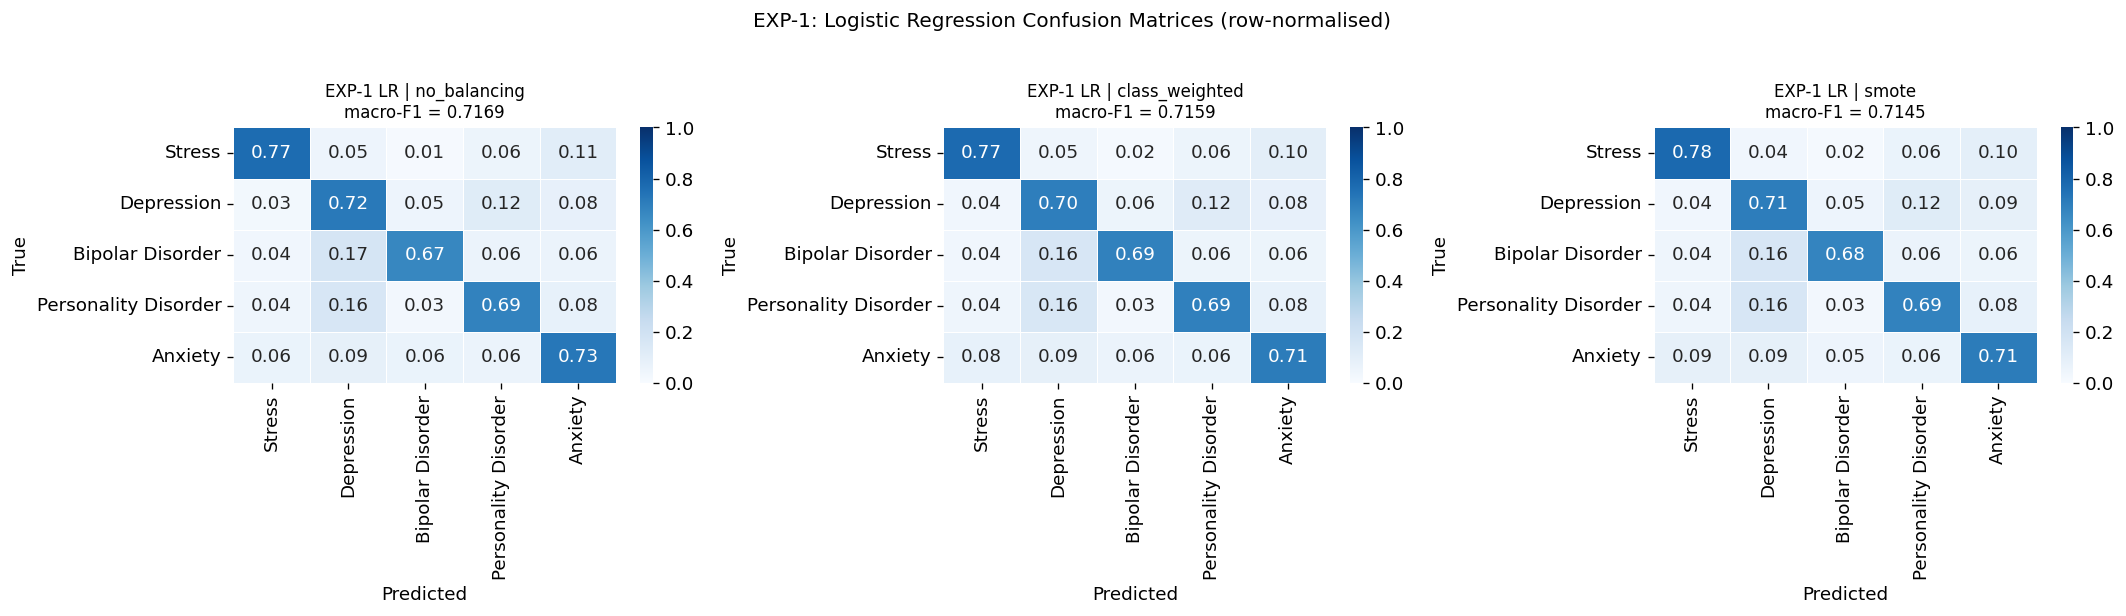


Best LR condition: no_balancing  (macro-F1 = 0.7169)
  [saved] /content/drive/MyDrive/Guna_CMPE_255_Project/figures/roc_lr_best.png


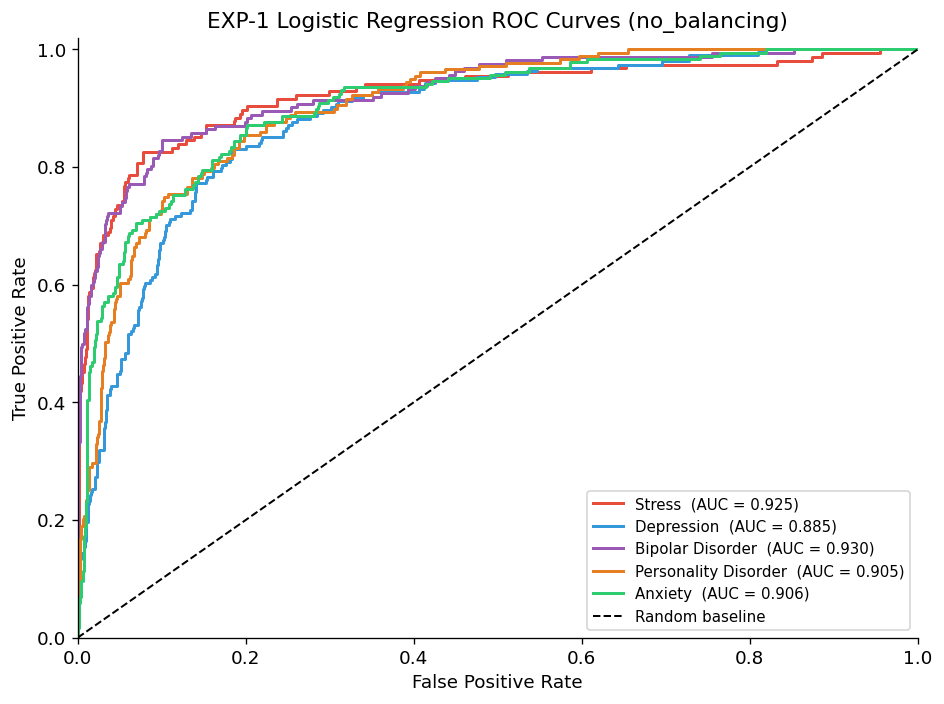

In [12]:
# ============================================================
# CELL 12 — EXP-1 Results: Summary Table + Confusion Matrix
# ============================================================

# ---- Summary table ----
display_cols = ['condition', 'best_C', 'cv_macro_f1', 'test_macro_f1', 'test_accuracy', 'test_roc_auc']
lr_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in lr_results])
print('EXP-1 — Logistic Regression Results')
print(lr_df[display_cols].to_string(index=False))

# ---- Confusion matrices for all three conditions ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, result in zip(axes, lr_results):
    cm_norm = result['_cm'].astype(float) / result['_cm'].sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, vmin=0, vmax=1, linewidths=0.4)
    ax.set_title(f'EXP-1 LR | {result["condition"]}\nmacro-F1 = {result["test_macro_f1"]:.4f}',
                 fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('EXP-1: Logistic Regression Confusion Matrices (row-normalised)', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cm_lr_all_conditions.png', dpi=150, bbox_inches='tight')
print(f'\nSaved → figures/cm_lr_all_conditions.png')
plt.show()

# ---- ROC curves for the best LR condition ----
# Pick the condition with the highest test macro-F1
best_lr_result = max(lr_results, key=lambda r: r['test_macro_f1'])
print(f'\nBest LR condition: {best_lr_result["condition"]}  '
      f'(macro-F1 = {best_lr_result["test_macro_f1"]:.4f})')

plot_roc_curves(
    y_test, best_lr_result['_y_proba'], CLASS_NAMES,
    title=f'EXP-1 Logistic Regression ROC Curves ({best_lr_result["condition"]})',
    save_path=FIGURES_DIR / 'roc_lr_best.png',
)

## 4. EXP-2 — Linear SVM

Linear SVM (support vector machine) with TF-IDF features is another strong
text classification baseline.  It often outperforms Logistic Regression on
high-dimensional sparse feature spaces.

**Important:** `LinearSVC` (sklearn's linear SVM) does **not** natively
produce probability estimates.  We wrap it in `CalibratedClassifierCV`
(Platt scaling via isotonic regression) so we can compute ROC-AUC.
This adds a small overhead but does not change the predicted classes.

In [13]:
# ============================================================
# CELL 13 — EXP-2: Linear SVM × 3 Balancing Conditions
# ============================================================

SVM_PARAM_GRID = {'estimator__C': [0.01, 0.1, 1, 10]}

svm_results = []

for condition, (X_tr, y_tr, cw) in CONDITIONS.items():
    print(f'\n--- EXP-2 | Linear SVM | {condition} ---')

    # LinearSVC: fast linear SVM implementation optimised for large sparse datasets.
    # dual=True is generally faster when n_samples > n_features; here n_features >> n_samples
    # so dual=False is preferred but both work.  max_iter=2000 helps convergence.
    base_svc = LinearSVC(
        penalty='l2',
        loss='squared_hinge',
        class_weight=cw,
        max_iter=2000,
        random_state=RANDOM_SEED,
    )

    # CalibratedClassifierCV wraps LinearSVC with Platt scaling (cv=5) to produce
    # probability estimates needed for ROC-AUC calculation.
    calibrated_svc = CalibratedClassifierCV(estimator=base_svc, cv=3)

    # GridSearchCV: the parameter name must include 'estimator__' because
    # we're tuning C inside the CalibratedClassifierCV wrapper.
    gs = GridSearchCV(
        estimator=calibrated_svc,
        param_grid=SVM_PARAM_GRID,
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0,
        refit=True,
    )

    gs.fit(X_tr, y_tr)

    best_C  = gs.best_params_['estimator__C']
    best_cv = gs.best_score_
    print(f'  Best C = {best_C},  CV macro-F1 = {best_cv:.4f}')

    # Evaluate on test set
    best_svm = gs.best_estimator_
    y_pred   = best_svm.predict(X_test_tfidf)
    y_proba  = best_svm.predict_proba(X_test_tfidf)  # available because of CalibratedClassifierCV

    metrics = compute_metrics(y_test, y_pred, y_proba)
    print(f'  Test macro-F1 = {metrics["macro_f1"]:.4f}')
    print(metrics['classification_report'])

    # Save model and log metrics
    model_path = MODELS_DIR / f'svm_{condition}.joblib'
    joblib.dump(best_svm, model_path)
    print(f'  Model saved → {model_path.name}')

    save_metrics('EXP-2', 'LinearSVM', condition, metrics,
                 best_cv_score=best_cv, notes=f'best_C={best_C}')

    svm_results.append({
        'condition':     condition,
        'best_C':        best_C,
        'cv_macro_f1':   round(best_cv, 4),
        'test_macro_f1': metrics['macro_f1'],
        'test_accuracy': metrics['accuracy'],
        'test_roc_auc':  metrics['roc_auc_macro'],
        '_cm':           np.array(metrics['confusion_matrix']),
        '_y_pred':       y_pred,
        '_y_proba':      y_proba,
    })

print('\n✅ EXP-2 complete.')


--- EXP-2 | Linear SVM | no_balancing ---
  Best C = 1,  CV macro-F1 = 0.7153
  Test macro-F1 = 0.7156
                      precision    recall  f1-score   support

              Stress       0.74      0.79      0.77       155
          Depression       0.66      0.67      0.66       194
    Bipolar Disorder       0.80      0.71      0.75       162
Personality Disorder       0.69      0.71      0.70       179
             Anxiety       0.70      0.69      0.70       186

            accuracy                           0.71       876
           macro avg       0.72      0.72      0.72       876
        weighted avg       0.71      0.71      0.71       876

  Model saved → svm_no_balancing.joblib
  [saved] EXP-2 | LinearSVM | no_balancing | macro_f1=0.7156

--- EXP-2 | Linear SVM | class_weighted ---
  Best C = 1,  CV macro-F1 = 0.7156
  Test macro-F1 = 0.7145
                      precision    recall  f1-score   support

              Stress       0.74      0.79      0.76       155
   

EXP-2 — Linear SVM Results
     condition  best_C  cv_macro_f1  test_macro_f1  test_accuracy  test_roc_auc
  no_balancing       1       0.7153         0.7156         0.7123        0.9125
class_weighted       1       0.7156         0.7145         0.7112        0.9125
         smote      10       0.7609         0.7214         0.7180        0.9104
Saved → figures/cm_svm_all_conditions.png


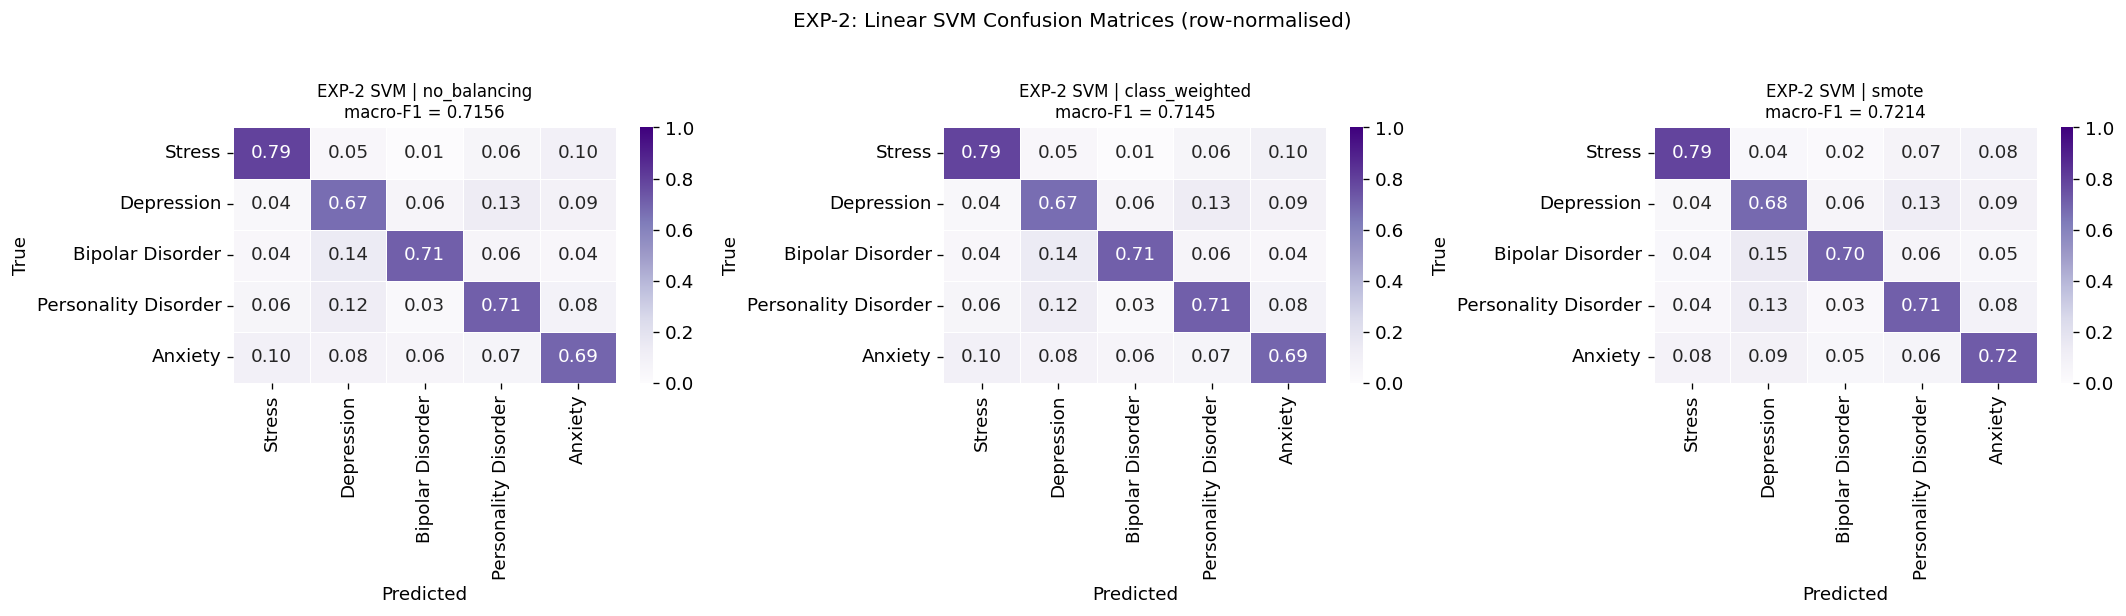


Best SVM condition: smote  (macro-F1 = 0.7214)
  [saved] /content/drive/MyDrive/Guna_CMPE_255_Project/figures/roc_svm_best.png


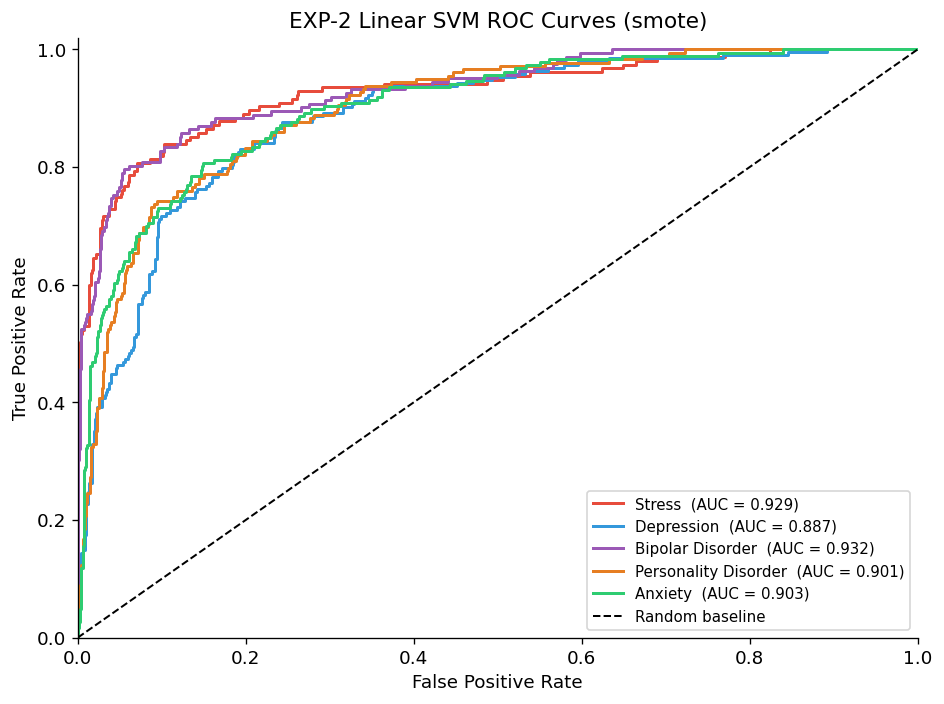

In [14]:
# ============================================================
# CELL 14 — EXP-2 Results: Summary Table + Confusion Matrix
# ============================================================

svm_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in svm_results])
print('EXP-2 — Linear SVM Results')
print(svm_df[display_cols].to_string(index=False))

# Confusion matrices for all three conditions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, result in zip(axes, svm_results):
    cm_norm = result['_cm'].astype(float) / result['_cm'].sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, vmin=0, vmax=1, linewidths=0.4)
    ax.set_title(f'EXP-2 SVM | {result["condition"]}\nmacro-F1 = {result["test_macro_f1"]:.4f}',
                 fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('EXP-2: Linear SVM Confusion Matrices (row-normalised)', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cm_svm_all_conditions.png', dpi=150, bbox_inches='tight')
print(f'Saved → figures/cm_svm_all_conditions.png')
plt.show()

# ROC curves for best SVM condition
best_svm_result = max(svm_results, key=lambda r: r['test_macro_f1'])
print(f'\nBest SVM condition: {best_svm_result["condition"]}  '
      f'(macro-F1 = {best_svm_result["test_macro_f1"]:.4f})')

plot_roc_curves(
    y_test, best_svm_result['_y_proba'], CLASS_NAMES,
    title=f'EXP-2 Linear SVM ROC Curves ({best_svm_result["condition"]})',
    save_path=FIGURES_DIR / 'roc_svm_best.png',
)

## 5. LP-Probe — Leakage Detection

**What is the LP-Probe?**

Reddit post labels in the Ghoshal corpus are derived from the *source subreddit*,
not from a clinical diagnosis.  This means models can accidentally learn
subreddit-specific surface cues — mod templates, trigger-warning prefixes,
in-group vocabulary — instead of genuine mental-health signal.

The LP-Probe runs Logistic Regression on **surface statistics only** (word count,
sentence count, punctuation density, capitalisation ratio, average word length).
There is zero lexical content — the model cannot see any words.

**Interpretation:**
- macro-F1 **≤ 0.40** → surface structure alone does not predict class well.
  Our preprocessing-stripping step is working.  ✅ Proceed.
- macro-F1 **≥ 0.50** → 🚨 **RED FLAG**: the model can classify posts
  using only surface formatting.  Go back to NB-02 and improve the
  leakage-stripping step before running XGBoost or DistilBERT.

In [ ]:
# ============================================================
# CELL 15 — LP-Probe: Logistic Regression on Surface Stats Only
# ============================================================

print('Running LP-Probe (surface stats only — no lexical content)...')
print(f'Feature dimensionality: {X_train_eng.shape[1]} surface/NRC features')
print('(No TF-IDF, no word n-grams — purely formatting statistics)\n')

lp_lr = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_SEED,
)

lp_gs = GridSearchCV(
    estimator=lp_lr,
    param_grid={'C': [0.01, 0.1, 1, 10]},
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,
)

lp_gs.fit(X_train_eng, y_train)
y_pred_lp  = lp_gs.best_estimator_.predict(X_test_eng)
y_proba_lp = lp_gs.best_estimator_.predict_proba(X_test_eng)

lp_metrics = compute_metrics(y_test, y_pred_lp, y_proba_lp)

print(f'LP-Probe best C    : {lp_gs.best_params_["C"]}')
print(f'LP-Probe CV macro-F1  : {lp_gs.best_score_:.4f}')
print(f'LP-Probe test macro-F1: {lp_metrics["macro_f1"]:.4f}')
print()
print(lp_metrics['classification_report'])

save_metrics('LP-Probe', 'LogisticRegression', 'no_balancing', lp_metrics,
             best_cv_score=lp_gs.best_score_,
             notes='surface_stats_only_no_lexical_content')

In [16]:
# ============================================================
# CELL 16 — LP-Probe: Red-Flag Check
# ============================================================

LEAKAGE_THRESHOLD = 0.50  # any LP macro-F1 above this is a preprocessing red flag
LP_WARN_LEVEL     = 0.40  # above this is noteworthy but not an immediate blocker

lp_f1 = lp_metrics['macro_f1']

print('=' * 60)
print('  LP-PROBE RESULT')
print('=' * 60)
print(f'  Macro-F1 (surface stats only) = {lp_f1:.4f}')
print()

if lp_f1 >= LEAKAGE_THRESHOLD:
    # A macro-F1 >= 0.50 on surface features means the model can classify
    # posts without reading any words — strong indicator of subreddit-style leakage.
    print('  🚨 RED FLAG: macro-F1 >= 0.50 on surface features.')
    print('     Surface formatting cues are strong predictors of class.')
    print('     Action: revisit the leakage-stripping step in Notebook 02')
    print('     before running XGBoost or DistilBERT.')
    print()
    raise RuntimeError(
        f'LP-Probe macro-F1 = {lp_f1:.4f} >= {LEAKAGE_THRESHOLD}. '
        'Fix subreddit-style leakage before proceeding.'
    )
elif lp_f1 >= LP_WARN_LEVEL:
    print(f'  ⚠️  CAUTION: macro-F1 ({lp_f1:.4f}) is between 0.40 and 0.50.')
    print('     Some surface signal exists, but it is below the hard threshold.')
    print('     Consider whether this is acceptable for your use case.')
else:
    # This is the expected outcome: near-random performance on surface features,
    # confirming that the model must rely on lexical content to classify posts.
    print(f'  ✅ PASS: macro-F1 = {lp_f1:.4f} < {LP_WARN_LEVEL}')
    print('     Surface features alone cannot classify posts reliably.')
    print('     Leakage stripping is working correctly.')
    print('     Safe to proceed to Notebook 05 (XGBoost).')

print('=' * 60)

  LP-PROBE RESULT
  Macro-F1 (surface stats only) = 0.1917

  ✅ PASS: macro-F1 = 0.1917 < 0.4
     Surface features alone cannot classify posts reliably.
     Leakage stripping is working correctly.
     Safe to proceed to Notebook 05 (XGBoost).


## 6. Results Summary

Read `results/metrics.csv` (which now contains EXP-1, EXP-2, and LP-Probe rows)
and display a consolidated comparison table.

NB-04 Results Summary
exp_name              model      condition  macro_f1  weighted_f1  roc_auc_macro  accuracy  best_cv_score
   EXP-1 LogisticRegression class_weighted    0.7159       0.7130         0.9106    0.7123       0.706454
   EXP-1 LogisticRegression   no_balancing    0.7169       0.7143         0.9102    0.7135       0.703747
   EXP-1 LogisticRegression          smote    0.7145       0.7118         0.9109    0.7112       0.756515
   EXP-2          LinearSVM class_weighted    0.7145       0.7114         0.9125    0.7112       0.715599
   EXP-2          LinearSVM   no_balancing    0.7156       0.7125         0.9125    0.7123       0.715348
   EXP-2          LinearSVM          smote    0.7214       0.7184         0.9104    0.7180       0.760869
LP-Probe LogisticRegression   no_balancing    0.1917       0.2030         0.5901    0.2603       0.207279

Saved → figures/nb04_macro_f1_summary.png


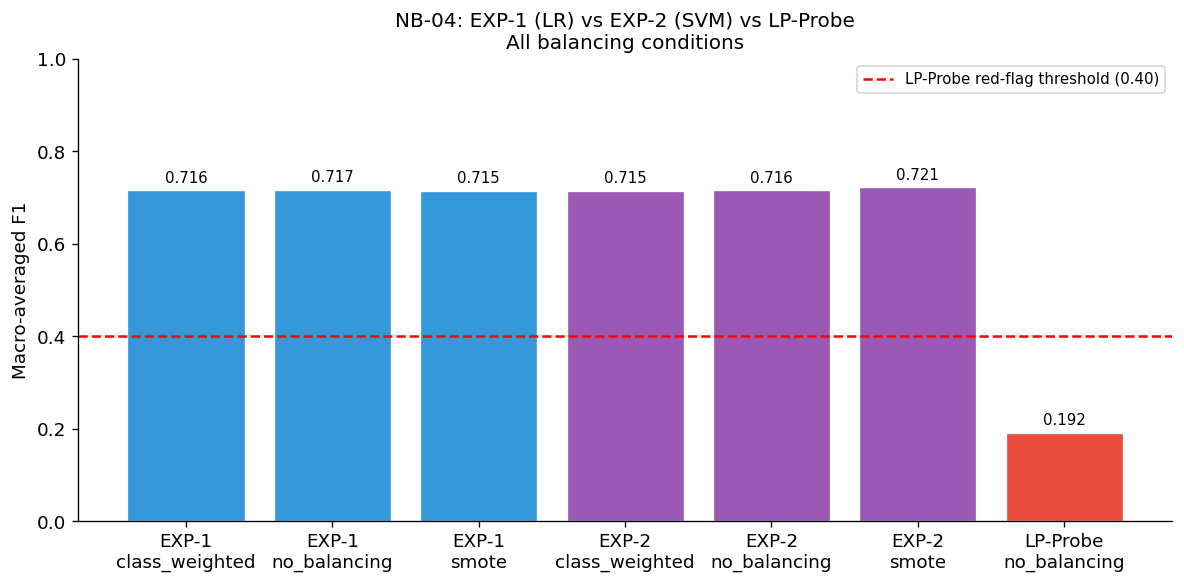


✅ Notebook 04 complete.
   Results written to: /content/drive/MyDrive/Guna_CMPE_255_Project/results/metrics.csv
   Models saved in   : /content/drive/MyDrive/Guna_CMPE_255_Project/models
   Figures saved in  : /content/drive/MyDrive/Guna_CMPE_255_Project/figures


In [17]:
# ============================================================
# CELL 17 — Final Summary: Load metrics.csv and Display
# ============================================================

# Read all rows written so far (EXP-1 × 3, EXP-2 × 3, LP-Probe × 1)
metrics_df = pd.read_csv(METRICS_CSV)

# Filter to just this notebook's experiments for a clean display
nb04_exps = metrics_df[metrics_df['exp_name'].isin(['EXP-1', 'EXP-2', 'LP-Probe'])].copy()

# Sort for readability
nb04_exps = nb04_exps.sort_values(['exp_name', 'condition']).reset_index(drop=True)

display_cols = ['exp_name', 'model', 'condition', 'macro_f1', 'weighted_f1',
                'roc_auc_macro', 'accuracy', 'best_cv_score']

print('NB-04 Results Summary')
print('=' * 80)
print(nb04_exps[display_cols].to_string(index=False))

# ---- Bar chart: macro-F1 comparison ----
fig, ax = plt.subplots(figsize=(10, 5))

# Build labels like 'EXP-1\nno_balancing'
nb04_exps['bar_label'] = nb04_exps['exp_name'] + '\n' + nb04_exps['condition']

colors = ['#3498DB', '#3498DB', '#3498DB',   # EXP-1 (blue shades)
          '#9B59B6', '#9B59B6', '#9B59B6',   # EXP-2 (purple shades)
          '#E74C3C']                          # LP-Probe (red)

bars = ax.bar(nb04_exps['bar_label'], nb04_exps['macro_f1'],
              color=colors[:len(nb04_exps)], edgecolor='white', linewidth=0.8)

# Red dashed line at 0.40 — the LP-Probe red-flag threshold
ax.axhline(y=0.40, color='red', linestyle='--', lw=1.5,
           label='LP-Probe red-flag threshold (0.40)')

ax.set_ylim(0, 1.0)
ax.set_ylabel('Macro-averaged F1', fontsize=11)
ax.set_title('NB-04: EXP-1 (LR) vs EXP-2 (SVM) vs LP-Probe\nAll balancing conditions', fontsize=12)
ax.legend(fontsize=9)

for bar, val in zip(bars, nb04_exps['macro_f1']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'nb04_macro_f1_summary.png', dpi=150, bbox_inches='tight')
print(f'\nSaved → figures/nb04_macro_f1_summary.png')
plt.show()

print('\n✅ Notebook 04 complete.')
print(f'   Results written to: {METRICS_CSV}')
print(f'   Models saved in   : {MODELS_DIR}')
print(f'   Figures saved in  : {FIGURES_DIR}')